<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB4_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.linear_model import Lasso, Ridge
import matplotlib.pyplot as plt

Initializing the $(\beta_i)_{i= 0}^{49}$ coefficients:
$$\beta_3 = 7\\\beta_8 = 1\\\beta_{20} = 4\\\beta_{30} = 2\\\beta_{40} = 9\\\beta_i = 0 \hspace{0.5cm} otherwise $$

In [2]:
beta = [0] * 50
beta[3] = 7
beta[8] = 1
beta[20] = 4
beta[30] = 2
beta[40] = 9

Generating test dataset.
$$x_i \sim \mathcal{U}(0, 1)\\ y = X\beta + \varepsilon\\ \varepsilon \sim \mathcal{N}(0, 3^2)$$


In [3]:
np.random.seed(42)
def generate_set(sample_size):
    """
    A function generating a set of 49 features (one beta in our ground truth model is an intercept) with the given
    sample size.
    """
    return np.random.uniform(0, 1, (sample_size, 49))

test_sample_size = int(1e3)
X_test = generate_set(test_sample_size)
f_x_test = X_test @ beta[1:] + beta[0]
test_noise = np.random.normal(0, 3, test_sample_size)
Y_test = f_x_test + test_noise
print(f"Theoretical variance = {test_noise.var():.2f}.")

Theoretical variance = 9.28.


Generating lambdas:
$$\lambda_i = 10^i, \hspace{0.5cm} i\in\{-3, -2.94, -2.88, \dots, 2.94, 3\}$$

In [4]:
lambdas = 10**np.linspace(-3, 3, 101)

Error decomposition:
$$Y = f(X) + \varepsilon\\[0.2cm]
Err_{x_0} = \mathbb{E}[(Y - \hat{f}(x_0))^2|X = x_0] =\\[0.2cm]
\mathbb{E}[(f(x_0) + \varepsilon - \hat{f}(x_0))^2] =\\[0.2cm]
\mathbb{E}[((f(x_0)- \hat{f}(x_0)) + \varepsilon )^2] =\\[0.2cm]
\mathbb{E}[(f(x_0)- \hat{f}(x_0))^2 + \varepsilon^2 + 2\varepsilon(f(x_0)- \hat{f}(x_0)) ] =^{\varepsilon, \hat{f}(x_0)  - independent}\\[0.2cm]
\mathbb{E}[(f(x_0)- \hat{f}(x_0))^2] + \mathbb{E}[\varepsilon^2] + 2\mathbb{E}[\varepsilon]\mathbb{E}[f(x_0)- \hat{f}(x_0)]=^{\mathbb{E}[\varepsilon] = 0}\\[0.2cm]
\sigma^2 + \mathbb{E}[(f(x_0)+ \mathbb{E}[\hat{f}(x_0)] -\mathbb{E}[\hat{f}(x_0)] - \hat{f}(x_0))^2]=\\[0.2cm]
\sigma^2 + \mathbb{E}[(f(x_0) -\mathbb{E}[\hat{f}(x_0)])^2] + \mathbb{E}[(\hat{f}(x_0) - \mathbb{E}[\hat{f}(x_0)])^2] - \mathbb{E}[(f(x_0) -\mathbb{E}[\hat{f}(x_0)])(\hat{f}(x_0) - \mathbb{E}[\hat{f}(x_0)])]=\\[0.2cm]
\sigma^2 + (\mathbb{E}[f^2(x_0)] - 2\mathbb{E}[f(x_0)]\mathbb{E}[\hat{f}(x_0)] + \mathbb{E}[\hat{f^2}(x_0)]) + \mathbb{E}[(\hat{f}(x_0) - \mathbb{E}[\hat{f}(x_0)])^2] - \mathbb{E}[(f(x_0) -\mathbb{E}[\hat{f}(x_0)])(\hat{f}(x_0) - \mathbb{E}[\hat{f}(x_0)])]=\\^{\mathbb{E}[f(x_0)] = f(x_0)}\\[0.2cm]
\sigma^2 + \text{Bias}^2(\hat{f}(x_0)) + \text{Var}(\hat{f}(x_0))\\[0.2cm]
$$

In summary:
$$Err_{x_0} = \sigma^2 + \text{Bias}^2(\hat{f}(x_0)) + \text{Var}(\hat{f}(x_0))\\[0.2cm]
\text{Bias}(\hat{f}(x_0)) = \mathbb{E}[\hat{f}(x_0)] - f(x_0)\\[0.2cm]
\text{Var}(\hat{f}(x_0)) = \mathbb{E}[(\hat{f}(x_0) - \mathbb{E}[\hat{f}(x_0)])^2]
$$

We will analize each of these components individually and average them over the whole test dataset to inspect the $\lambda$ parameter effect on the model complexity in ridge and lasso regression.

# Ridge regression

In [5]:
train_sample_size = 40
repetitions = 100
ridge_bias = list()
ridge_var = list()
ridge_mse = list()

for l in lambdas:
    ridge_predictions = np.zeros((test_sample_size, repetitions))

    for i in range(repetitions):
        # Generating train_set
        ridge_regression = Ridge(alpha = l, fit_intercept= True)
        X_train = generate_set(train_sample_size)
        Y_train = X_train @ beta[1:] + beta[0] + np.random.normal(0, 3, train_sample_size)

        # Fitting model
        ridge_regression.fit(X_train, Y_train)

        # Saving results
        ridge_predictions[:, i] = ridge_regression.predict(X_test)

    # Error decomposition
    bias = ridge_predictions.mean(axis= 1) - f_x_test
    variance = ridge_predictions.var(axis= 1)
    mse = ((ridge_predictions - Y_test.reshape(test_sample_size, 1))**2).mean(axis= 1)

    ridge_bias.append((bias**2).mean())
    ridge_var.append(variance.mean())
    ridge_mse.append(mse.mean())


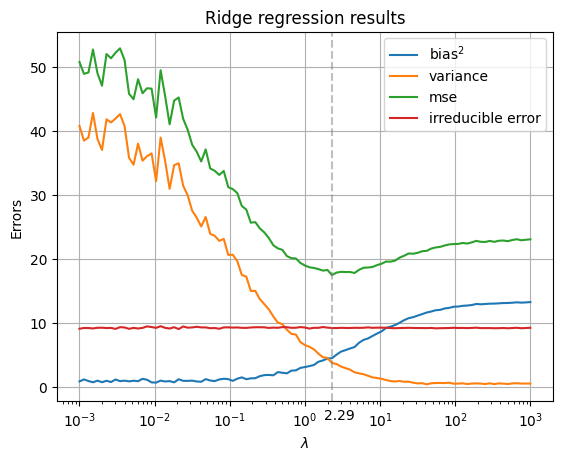

Average irreducible error = 9.25.


In [10]:
plt.plot(lambdas, ridge_bias, label= "bias$^2$")
plt.plot(lambdas, ridge_var, label= "variance")
plt.plot(lambdas, ridge_mse, label= "mse")
plt.plot(lambdas, (np.array(ridge_mse) - np.array(ridge_bias) - np.array(ridge_var)), label= "irreducible error")
plt.axvline(x = lambdas[ridge_mse.index(min(ridge_mse))], color= "gray", linestyle= "dashed", alpha= 0.5)
plt.text(x= lambdas[ridge_mse.index(min(ridge_mse))] - 0.5, y = -5, s= f"{lambdas[ridge_mse.index(min(ridge_mse))]:.2f}")
plt.xscale("log")
plt.legend()
plt.title("Ridge regression results")
plt.xlabel(r"$\lambda$")
plt.ylabel("Errors")
plt.grid()
plt.show()

print(f"Average irreducible error = {(np.array(ridge_mse) - np.array(ridge_bias) - np.array(ridge_var)).mean():.2f}.")

The results are compliant with the theory - increasing the complexity penalty results in lower variance and higher bias (ignoring minor fluctuations that are caused by randomness of the generated train sets, as $repetitions \to \infty$ we will obtain monotonic relations). The mean squared error curve is U-shaped with the optimal trade-off at $\lambda = 2.29$. The irreducible error is consistant at $9.25$, which is almost exatctly the theoretical $\sigma^2$.

# LASSO

In [7]:
train_sample_size = 40
repetitions = 100
lasso_bias = list()
lasso_var = list()
lasso_mse = list()

for l in lambdas:
    lasso_predictions = np.zeros((test_sample_size, repetitions))

    for i in range(repetitions):
        # Generating train_set
        lasso_regression = Lasso(alpha = l, fit_intercept= True, max_iter= 100000)
        X_train = generate_set(train_sample_size)
        Y_train = X_train @ beta[1:] + beta[0] + np.random.normal(0, 3, train_sample_size)

        # Fitting model
        lasso_regression.fit(X_train, Y_train)

        # Saving results
        lasso_predictions[:, i] = lasso_regression.predict(X_test)

    # Error decomposition
    bias = lasso_predictions.mean(axis= 1) - f_x_test
    variance = lasso_predictions.var(axis= 1)
    mse = ((lasso_predictions - Y_test.reshape(test_sample_size, 1))**2).mean(axis= 1)

    lasso_bias.append((bias**2).mean())
    lasso_var.append(variance.mean())
    lasso_mse.append(mse.mean())


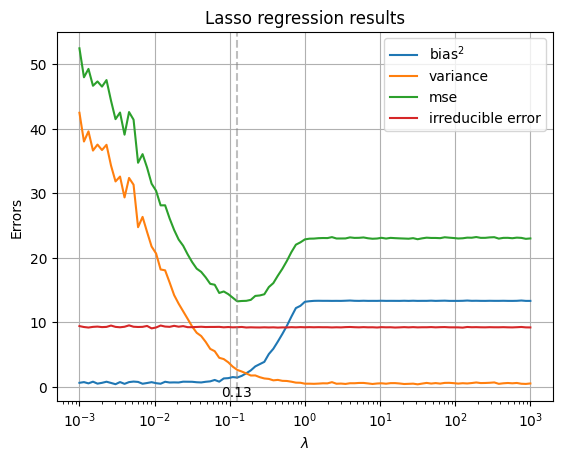

Average irreducible error = 9.23.


In [12]:
plt.plot(lambdas, lasso_bias, label= "bias$^2$")
plt.plot(lambdas, lasso_var, label= "variance")
plt.plot(lambdas, lasso_mse, label= "mse")
plt.plot(lambdas, (np.array(lasso_mse) - np.array(lasso_bias) - np.array(lasso_var)), label= "irreducible error")
plt.axvline(x = lambdas[lasso_mse.index(min(lasso_mse))], color= "gray", linestyle= "dashed", alpha= 0.5)
plt.text(x= lambdas[lasso_mse.index(min(lasso_mse))] - 0.05, y = -1.5, s= f"{lambdas[lasso_mse.index(min(lasso_mse))]:.2f}")
plt.xscale("log")
plt.legend()
plt.title("Lasso regression results")
plt.xlabel(r"$\lambda$")
plt.ylabel("Errors")
plt.grid()
plt.show()
print(f"Average irreducible error = {(np.array(lasso_mse) - np.array(lasso_bias) - np.array(lasso_var)).mean():.2f}.")

The LASSO results are similar to the ridge regression case. Bias is ascending, variance is descending, the MSE is U-shaped withe the minimum at $\lambda = 0.14$ and the irreducible error is constant at $9.23$. It is also worth noticing, that the error factors become constant for $\lambda > 1$. This is due to the fact, that at that point the penalty is so large relative to the model's regression capacity, that all the coefficients are zeroed-out except the intercept (which is not penalized). The coefficient paths are shown below.

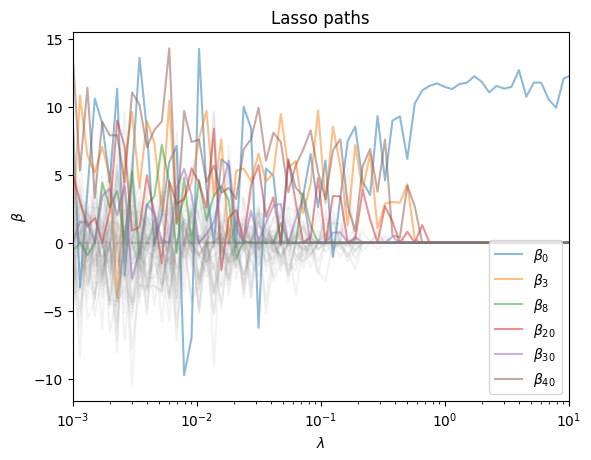

In [11]:
lasso_coefficients = np.zeros((50, len(lambdas)))
for i, l in enumerate(lambdas):
    lasso_regression = Lasso(alpha = l, fit_intercept= True, max_iter= 100000)
    X_train = generate_set(train_sample_size)
    Y_train = X_train @ beta[1:] + beta[0] + np.random.normal(0, 3, train_sample_size)

    # Fitting model
    lasso_regression.fit(X_train, Y_train)
    lasso_coefficients[1:, i] = lasso_regression.coef_
    lasso_coefficients[0, i] = lasso_regression.intercept_

plt.figure()
for i in range(50):
    if i in [0, 3, 8, 20, 30, 40]:
        plt.plot(lambdas, lasso_coefficients[i, :], alpha= 0.5, label= f"$\\beta_{{{i}}}$")
    else:
        plt.plot(lambdas, lasso_coefficients[i, :], alpha= 0.1, color= "gray")

plt.xlim((0.001, 10))
plt.legend(loc= "lower right")
plt.xscale("log")
plt.title("Lasso paths")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\beta$")
plt.show()

# Results discussion

### Optimal trade-off
The optimal $\lambda$ can be chosen as the one that minimizes the mean squared error. By the error decomposition worked out previously it is clear that this is the parameter for which the increase of bias is best compensated by variance-reduction.

### Bias-variance trade-off in Lasso and Ridge regression

The $L1$ penalty used in lasso regression tends to shrink some coefficients to zero, whereas the $L2$ penalty reduces the model complexity in a more regular manner - the parameters are shrinked more uniformly. Since ridge regression does not result in feature selection, its reduction of model complexity with respect to the $\lambda$ parameter (i.e. growth of the bias and drop of the variance) is more smooth than in lasso. In our example it can be noticed, that the curves move more rapidly for lasso.

### How to choose between Ridge and Lasso regression?

The feature selection side of lasso is a key distinguismnet between these two apporaches. The $L1$ penalty will perform better in cases when only a handful of features actually have an effect on the target (the model is sparse). When on the other hand all or the vast majority of features are relevant but we still want to introduce penalty because of the ill-conditioning of the $X^TX$ matrix, ridge regression will be a better choice because it will reduce the multicollinearity of the features without rejecting them from the model complitely.

In the example above, lasso regression is clearly a better choice - the features are not correlated with one another but most of them have no effect on the target in the ground truth model, which results in optimal $MSE$ level lower than in ridge regression.